libaraies

In [2]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, resample_poly
import neurokit2 as nk
from scipy.signal import find_peaks
import seaborn as sns
from scipy.stats import wilcoxon

# Pandas display settings (optional)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 0)

load files

In [3]:
# RESP FILE PATHS
RI1_3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5"
RI2_3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_6_p5_3_nRB3_20250621_131158_merged.h5"
BLRI_s3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s3_6_p5_3_nRB3_20250621_123634_merged.h5"
BLRI_s4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s4_7_p5_2_nRB3_20250621_144806_merged.h5"
RI1_4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_7_p5_2_nRB3_20250621_150707_merged.h5"
RI2_4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_7_p5_2_nRB3_20250621_152519_merged.h5"
RI1_2_3_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s2_3_p5_3_nRB3_20250622_104059_merged (1).h5"
RI2_2_3_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s2_3_p5_3_nRB3_20250622_110216_merged.h5"
RI1_4_8_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_8_p5_1_nRB3_20250621_165214_merged.h5"
RI2_4_8_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_8_p5_1_nRB3_20250621_171318_merged.h5"
RI1_1_1_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s1_1_p5_2_nRB6_20250622_143958_merged.h5"
RI2_1_1_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s1_1_p5_2_nRB6_20250622_150457_merged.h5"
RI1_1_2_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s1_2_p5_1_nRB6_20250622_170742_merged.h5"
RI2_1_2_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s1_2_p5_1_nRB6_20250622_173049_merged.h5"
RI1_2_4_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s2_4_p5_4_nRB3_20250622_123424_merged.h5"
RI2_2_4_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s2_4_p5_4_nRB3_20250622_125648_merged.h5"
RI2_3_5_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_5_p5_4_nRB3_20250621_112618_merged.h5"
RI1_3_5_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_5_p5_4_nRB3_20250621_105014_merged.h5"


# BORIS CSVs (no comma at the end or it makes a tuple)
RI1_3_6_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s3_6_p5_3_nRB3_HEEPS.csv")
RI2_3_6_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s3_6_p_5_3_nRB3_2025062.csv")
RI1_4_7_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s4_7_p5_2_nRB3_HEEPS.csv")
RI2_4_7_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s4_7_p5_2_nRB3_HEEPS.csv")
RI1_2_3_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s2_3_p5_3_nRB3_20250622_104059.1.csv")
RI2_2_3_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s2_3_p5_3_nRB3_20250622_1102116.1.csv")
RI1_4_8_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s4_8_p5_1_nRB3_HEEPS.csv")
RI2_4_8_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s4_8_p5_1_nRB3_20250621_HEEPS.csv")
RI1_1_1_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s1_1_p5_2_nRB6_20250622_143958.1.csv")
RI2_1_1_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s1_1_p5_2_nRB6_20250622_150457.1.csv")
RI1_1_2_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s1_2_p5_1_nRB6_20250622_170742.1.csv")
RI2_1_2_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s1_2_p5_1_nRB6_20250622_173049.1.csv")
RI1_2_4_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s2_4_p5_4_nRB3_20250622_123424.1.csv")
RI2_2_4_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s2_4_p5_4_nRB3_20250622_125648.1.csv")
RI2_3_5_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s3_5_p5_4_nRB3_20250621.csv")


In [4]:
ri1_h5_paths = {
    "RI1_3_6": RI1_3_6_h5_path,
    "RI1_4_7": RI1_4_7_h5_path,  
    "RI1_2_3": RI1_2_3_h5_path,
    "RI1_4_8": RI1_4_8_h5_path,
    "RI1_1_1": RI1_1_1_h5_path,
    "RI1_1_2": RI1_1_2_h5_path,
    "RI1_2_4": RI1_2_4_h5_path,
    "RI1_3_5": RI1_3_5_h5_path,
}

In [5]:
ri2_h5_paths = {
    "RI2_3_6": RI2_3_6_h5_path,
    "RI2_4_7": RI2_4_7_h5_path,
    "RI2_2_3": RI2_2_3_h5_path,
    "RI2_4_8": RI2_4_8_h5_path,
    "RI2_1_1": RI2_1_1_h5_path,
    "RI2_1_2": RI2_1_2_h5_path,
    "RI2_2_4": RI2_2_4_h5_path,
    "RI2_3_5": RI2_3_5_h5_path,
}


In [6]:
ri1_boris_data = {
    "RI1_3_6": RI1_3_6_boris.copy(),
    "RI1_4_7": RI1_4_7_boris.copy(),
    "RI1_2_3": RI1_2_3_boris.copy(),
    "RI1_4_8": RI1_4_8_boris.copy(),
    "RI1_1_1": RI1_1_1_boris.copy(),
    "RI1_1_2": RI1_1_2_boris.copy(),
    "RI1_2_4": RI1_2_4_boris.copy(),
}


In [7]:
ri2_boris_data = {
    "RI2_3_6": RI2_3_6_boris.copy(),
    "RI2_4_7": RI2_4_7_boris.copy(),
    "RI2_2_3": RI2_2_3_boris.copy(),
    "RI2_4_8": RI2_4_8_boris.copy(),
    "RI2_1_1": RI2_1_1_boris.copy(),
    "RI2_1_2": RI2_1_2_boris.copy(),
    "RI2_2_4": RI2_2_4_boris.copy(),
    "RI2_3_5": RI2_3_5_boris.copy(),
}


load_clean_resp_signal function for loading and preprocessing respiration data:

Reads raw resp signal and metadata from .h5

Computes original sampling rate (fs)

Applies a low-pass filter before downsampling to avoid aliasing

Downsamples the signal to your target_rate (default 100 Hz)

Applies a bandpass filter (0.1–20 Hz) with NeuroKit to clean the signal further

Creates a time vector that matches the cleaned signal length and sampling rate

This function returns:
rsp_cleaned: the cleaned, filtered, downsampled respiratory signal array

time_vector: time points corresponding to each sample in seconds

target_rate: the sampling rate after downsampling (e.g., 100 Hz)

You can then pass these outputs to functions like:
get_percent_change_resp_rate(signal=rsp_cleaned, times=time_vector, sniff_start, sniff_end)

get_delta_resp_rate(signal=rsp_cleaned, times=time_vector, sniff_end)

In [8]:
def load_clean_resp_signal(h5_file, target_rate=100):
    """
    Loads, filters, downsamples respiration from .h5, returns cleaned signal and time vector.
    """
    try:
        with h5py.File(h5_file, 'r') as f:
            resp = f['resp'][:].flatten()
            ekg_meta = dict(f['ekg_metadata'].attrs)
        duration_sec = ekg_meta['duration_sec']
        fs = len(resp) / duration_sec
    except Exception as e:
        print(f"Error loading {h5_file}: {e}")
        return None, None, None

    # Pre-filter before downsampling
    nyquist = fs / 2
    norm_cutoff = (target_rate / 2) / nyquist
    b, a = butter(N=4, Wn=norm_cutoff, btype='low')
    filtered_resp = filtfilt(b, a, resp)

    # Downsample
    downsample_factor = int(fs // target_rate)
    downsampled = resample_poly(filtered_resp, up=1, down=downsample_factor)

    # Bandpass filter with neurokit
    rsp_cleaned = nk.signal_filter(
        downsampled,
        lowcut=0.1,
        highcut=20,
        method="butterworth",
        sampling_rate=target_rate,
        order=2
    )

    # Generate matching time vector
    time_vector = np.arange(len(rsp_cleaned)) / target_rate

    return rsp_cleaned, time_vector, target_rate

In [9]:
h5_paths = {
    "RI1_3_6": RI1_3_6_h5_path,
    "RI2_3_6": RI2_3_6_h5_path,
    "RI1_4_7": RI1_4_7_h5_path,
    "RI2_4_7": RI2_4_7_h5_path,
    "RI1_2_3": RI1_2_3_h5_path,
    "RI2_2_3": RI2_2_3_h5_path,
    "RI1_4_8": RI1_4_8_h5_path,
    "RI2_4_8": RI2_4_8_h5_path,
    "RI1_1_1": RI1_1_1_h5_path,
    "RI2_1_1": RI2_1_1_h5_path,
    "RI1_1_2": RI1_1_2_h5_path,
    "RI2_1_2": RI2_1_2_h5_path,
    "RI1_2_4": RI1_2_4_h5_path,
    "RI2_2_4": RI2_2_4_h5_path,
    "RI1_3_5": RI1_3_5_h5_path,
    "RI2_3_5": RI2_3_5_h5_path,
}


In [10]:
resp_data = {}

for label, path in h5_paths.items():
    print(f"Processing {label}...")
    signal, time, rate = load_clean_resp_signal(path)
    
    if signal is not None:
        resp_data[label] = {
            "signal": signal,
            "time": time,
            "sampling_rate": rate
        }
    else:
        print(f"Skipping {label}: failed to load.")

print("✅ All available signals loaded.")


Processing RI1_3_6...
Processing RI2_3_6...
Processing RI1_4_7...
Processing RI2_4_7...
Processing RI1_2_3...
Processing RI2_2_3...
Processing RI1_4_8...
Processing RI2_4_8...
Processing RI1_1_1...
Processing RI2_1_1...
Processing RI1_1_2...
Processing RI2_1_2...
Processing RI1_2_4...
Processing RI2_2_4...
Processing RI1_3_5...
Processing RI2_3_5...
✅ All available signals loaded.


In [11]:
print(RI1_3_6_boris.columns)


Index(['Observation id', 'Observation date', 'Description', 'Observation type',
       'Source', 'Time offset (s)', 'Coding duration', 'Media duration (s)',
       'FPS (frame/s)', 'Subject',
       'Observation duration by subject by observation', 'Behavior',
       'Behavioral category', 'Behavior type', 'Start (s)', 'Stop (s)',
       'Duration (s)', 'Media file name', 'Image index start',
       'Image index stop', 'Image file path start', 'Image file path stop',
       'Comment start', 'Comment stop'],
      dtype='object')


In [12]:
def build_behavior_duration_df(boris_dict):
    all_rows = []

    for session_name, df in boris_dict.items():
        # Add 'Condition' column extracted from 'Observation id' or session_name
        # We'll extract 'RI1' or 'RI2' from session_name keys or from Observation id column
        # Assuming session_name is like "RI1_3_6", "RI2_4_7", etc.
        condition = 'RI1' if 'RI1' in session_name else 'RI2'

        # Only keep rows with valid initiators
        df = df[df['Subject'].isin(['subject', 'social_agent'])].copy()

        # Group by Subject (initiator) and Behavior
        grouped = (
            df.groupby(['Subject', 'Behavior'])
            .agg(TotalDuration=('Duration (s)', 'sum'))
            .reset_index()
        )

        grouped['Condition'] = condition
        grouped['Session'] = session_name

        all_rows.append(grouped)

    return pd.concat(all_rows, ignore_index=True)

    # Optional: if your Subject column includes initiator labels (like 'subject'), you can clean here
    # But from your sample it looks like 'Subject' is initiator label, so you might want another column for mouse ID?
    # If you have mouse IDs, make sure to include or parse that elsewhere.

    return combined_df

# Build combined DataFrame for RI1 and RI2 BORIS data dictionaries
ri1_behavior_df = build_behavior_duration_df(ri1_boris_data)
ri2_behavior_df = build_behavior_duration_df(ri2_boris_data)

# Combine both conditions
all_behavior_df = pd.concat([ri1_behavior_df, ri2_behavior_df], ignore_index=True)

# Preview
print(all_behavior_df.head())


        Subject             Behavior  TotalDuration Condition  Session
0  social_agent  anogenital sniffing         11.656       RI1  RI1_3_6
1  social_agent        body sniffing          1.172       RI1  RI1_3_6
2  social_agent      facial sniffing         10.485       RI1  RI1_3_6
3       subject  anogenital sniffing         16.998       RI1  RI1_3_6
4       subject        body sniffing          2.068       RI1  RI1_3_6


In [27]:
# Sum total durations by Subject (initiator) and Condition
summary = all_behavior_df.groupby(['Subject', 'Condition'])['TotalDuration'].sum().unstack()
print(summary)


Condition         RI1      RI2
Subject                       
social_agent  126.763  997.608
subject       584.392  702.995


In [13]:
ri1_behavior_df = build_behavior_duration_df(ri1_boris_data)
ri2_behavior_df = build_behavior_duration_df(ri2_boris_data)
all_behavior_df = pd.concat([ri1_behavior_df, ri2_behavior_df], ignore_index=True)


C:\Users\sjs93\AppData\Local\Temp\ipykernel_28092\475055990.py:53: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


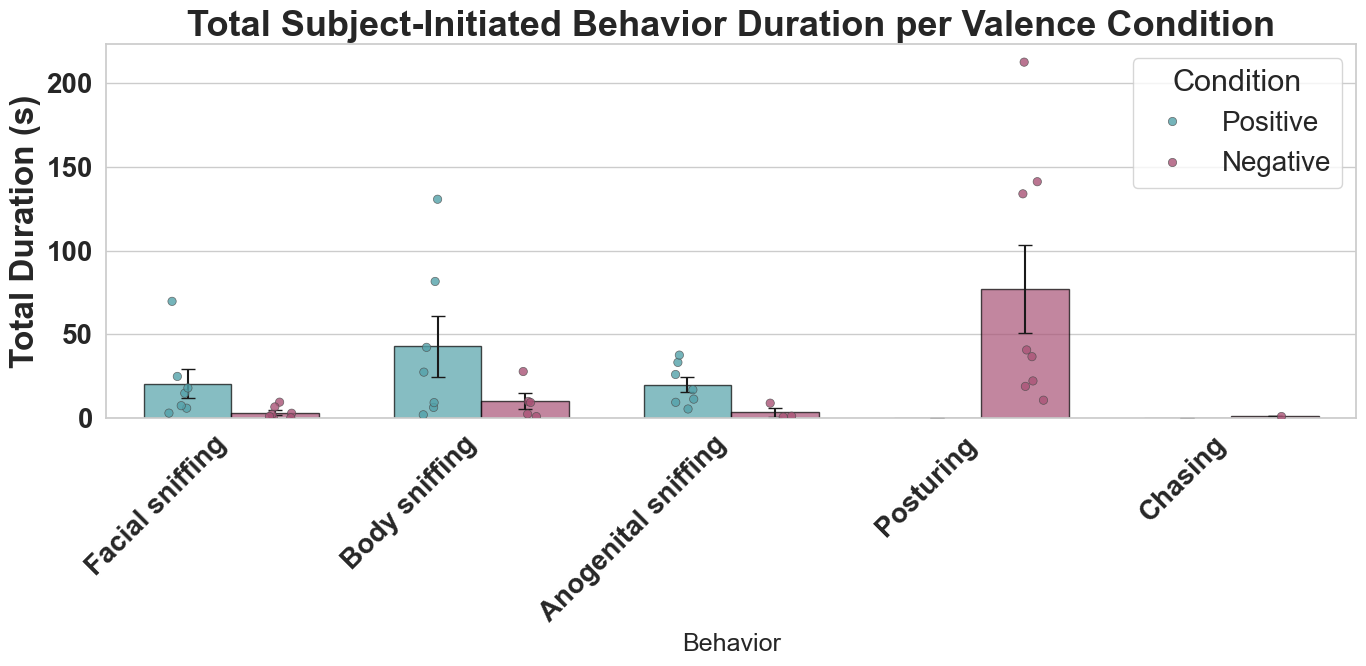

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Filter to subject-initiated behaviors and format behavior labels
plot_df = all_behavior_df[all_behavior_df['Subject'] == 'subject'].copy()
plot_df['Behavior'] = plot_df['Behavior'].str.capitalize()

# Define behavior order and color palette
behavior_order = ['Facial sniffing', 'Body sniffing', 'Anogenital sniffing', 'Posturing', 'Chasing']
condition_colors = {
    'RI1': (83/255, 161/255, 169/255),  # Positive
    'RI2': (169/255, 83/255, 118/255),  # Negative
}

# Calculate mean and SEM for each condition/behavior
summary_df = (
    plot_df.groupby(['Behavior', 'Condition'])
    .agg(mean_duration=('TotalDuration', 'mean'),
         sem_duration=('TotalDuration', lambda x: np.std(x, ddof=1)/np.sqrt(len(x)) if len(x) > 1 else 0))
    .reset_index()
)
summary_df['Behavior'] = pd.Categorical(summary_df['Behavior'], categories=behavior_order, ordered=True)

# Set up the figure
sns.set(style="whitegrid", font_scale=1.5)
plt.figure(figsize=(14, 7))

bar_width = 0.35
x = np.arange(len(behavior_order))

# Plot bars with error bars
for i, cond in enumerate(['RI1', 'RI2']):
    cond_df = summary_df[summary_df['Condition'] == cond].set_index('Behavior')
    cond_df = cond_df.reindex(behavior_order, fill_value=0)  # fill missing behaviors with 0

    positions = x + (i - 0.5) * bar_width

    plt.bar(
        positions,
        cond_df['mean_duration'],
        yerr=cond_df['sem_duration'],
        width=bar_width,
        label='Positive' if cond == 'RI1' else 'Negative',
        color=condition_colors[cond],
        alpha=0.7,
        capsize=5,
        edgecolor='black'
    )

# Overlay data points
sns.stripplot(
    data=plot_df,
    x='Behavior',
    y='TotalDuration',
    hue='Condition',
    order=behavior_order,
    dodge=True,
    jitter=True,
    palette={k: (*v, 1.0) for k, v in condition_colors.items()},
    alpha=0.8,
    size=6,
    edgecolor='gray',
    linewidth=0.5,
    zorder=10
)

# Clean up legend to only show Positive and Negative once
handles, labels = plt.gca().get_legend_handles_labels()
label_map = {'RI1': 'Positive', 'RI2': 'Negative'}
seen = set()
new_handles = []
new_labels = []
for h, l in zip(handles, labels):
    if l in label_map and label_map[l] not in seen:
        new_handles.append(h)
        new_labels.append(label_map[l])
        seen.add(label_map[l])
plt.legend(new_handles, new_labels, title='Condition', fontsize=20, title_fontsize=22)

# Format axes and title
plt.xticks(x, behavior_order, rotation=45, ha='right', fontsize=20, weight='bold')
plt.yticks(fontsize=20, weight='bold')
plt.ylabel('Total Duration (s)', fontsize=24, weight='bold')
plt.title('Total Subject-Initiated Behavior Duration per Valence Condition', fontsize=26, weight='bold')

plt.tight_layout()
plt.show()


C:\Users\sjs93\AppData\Local\Temp\ipykernel_28092\3300479487.py:62: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


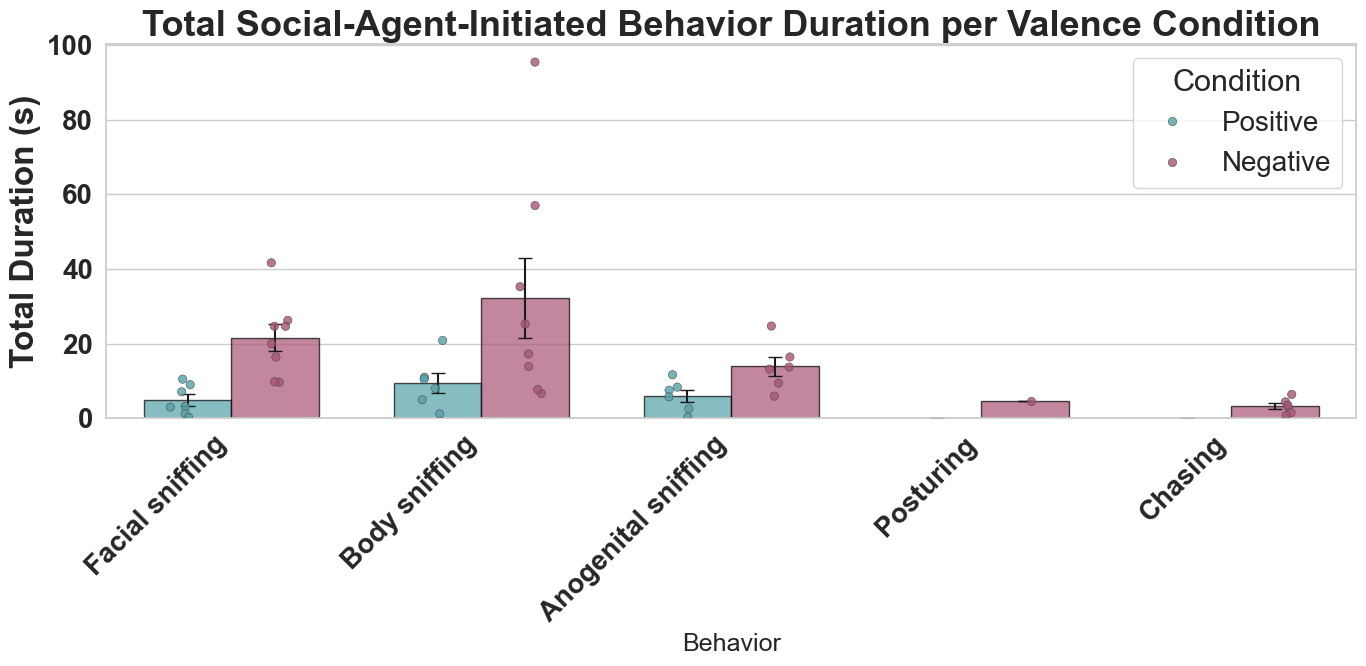

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Filter to social-agent-initiated behaviors and capitalize behavior labels
plot_df = all_behavior_df[all_behavior_df['Subject'] == 'social_agent'].copy()
plot_df['Behavior'] = plot_df['Behavior'].str.capitalize()

# Define behavior order and colors
behavior_order = ['Facial sniffing', 'Body sniffing', 'Anogenital sniffing', 'Posturing', 'Chasing']
condition_colors = {
    'RI1': (83/255, 161/255, 169/255),  # Positive
    'RI2': (169/255, 83/255, 118/255),  # Negative
}

# Compute summary stats
summary_df = (
    plot_df.groupby(['Behavior', 'Condition'])
    .agg(mean_duration=('TotalDuration', 'mean'),
         sem_duration=('TotalDuration', lambda x: np.std(x, ddof=1)/np.sqrt(len(x)) if len(x) > 1 else 0))
    .reset_index()
)
summary_df['Behavior'] = pd.Categorical(summary_df['Behavior'], categories=behavior_order, ordered=True)

# Set up figure
sns.set(style="whitegrid", font_scale=1.5)
plt.figure(figsize=(14, 7))
bar_width = 0.35
x = np.arange(len(behavior_order))

# Plot bar plots per condition
for i, cond in enumerate(['RI1', 'RI2']):
    cond_df = summary_df[summary_df['Condition'] == cond]
    means = []
    sems = []

    for beh in behavior_order:
        row = cond_df[cond_df['Behavior'] == beh]
        if not row.empty:
            means.append(row['mean_duration'].values[0])
            sems.append(row['sem_duration'].values[0])
        else:
            means.append(0)
            sems.append(0)

    positions = x + (i - 0.5) * bar_width

    plt.bar(
        positions,
        means,
        yerr=sems,
        width=bar_width,
        label='Positive' if cond == 'RI1' else 'Negative',
        color=condition_colors[cond],
        alpha=0.7,
        capsize=5,
        edgecolor='black'
    )

# Overlay individual data points
sns.stripplot(
    data=plot_df,
    x='Behavior',
    y='TotalDuration',
    hue='Condition',
    order=behavior_order,
    dodge=True,
    jitter=True,
    palette={k: (*v, 1.0) for k, v in condition_colors.items()},
    alpha=0.8,
    size=6,
    edgecolor='gray',
    linewidth=0.5,
    zorder=10
)

# Fix legend
handles, labels = plt.gca().get_legend_handles_labels()
label_map = {'RI1': 'Positive', 'RI2': 'Negative'}
seen = set()
new_handles, new_labels = [], []
for h, l in zip(handles, labels):
    if l in label_map and label_map[l] not in seen:
        new_handles.append(h)
        new_labels.append(label_map[l])
        seen.add(label_map[l])
plt.legend(new_handles, new_labels, title='Condition', fontsize=20, title_fontsize=22)

# Axis formatting
plt.xticks(x, behavior_order, rotation=45, ha='right', fontsize=20, weight='bold')
plt.yticks(fontsize=20, weight='bold')
plt.ylabel('Total Duration (s)', fontsize=24, weight='bold')
plt.title('Total Social-Agent-Initiated Behavior Duration per Valence Condition', fontsize=26, weight='bold')

plt.tight_layout()
plt.show()


C:\Users\sjs93\AppData\Local\Temp\ipykernel_28092\2842620177.py:33: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


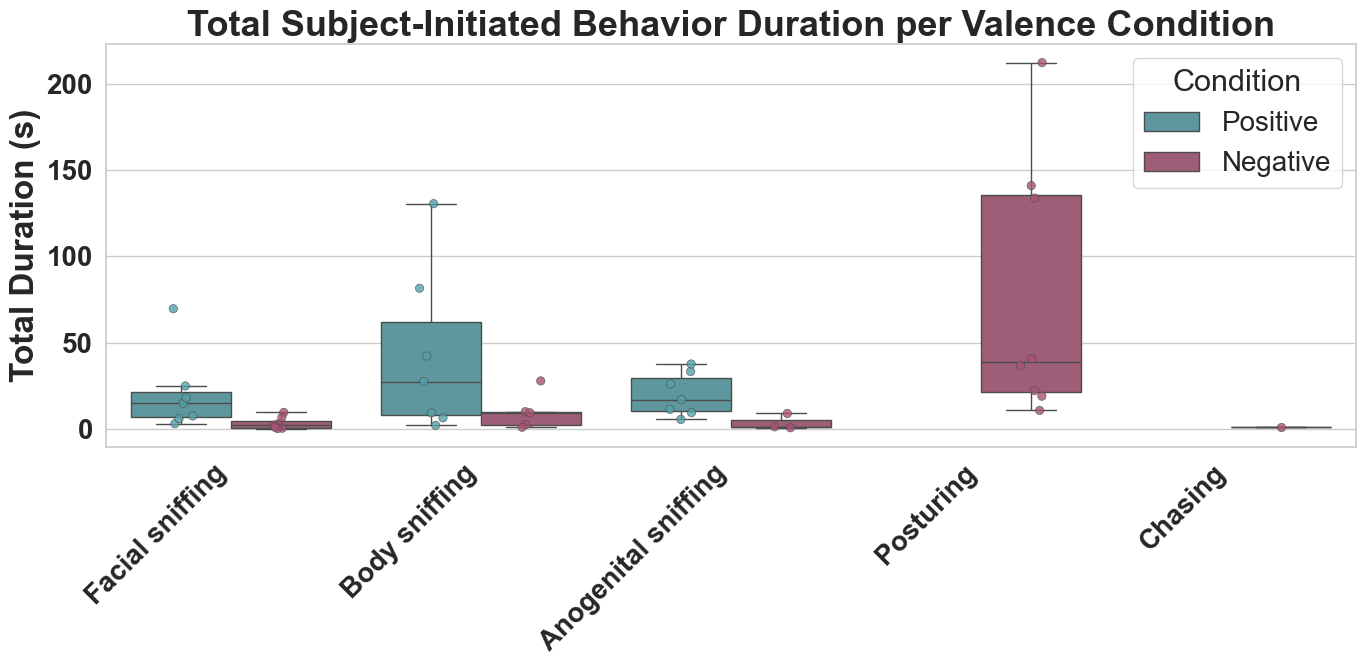

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for subject-initiated behaviors
plot_df = all_behavior_df[all_behavior_df['Subject'] == 'subject'].copy()
plot_df['Behavior'] = plot_df['Behavior'].str.capitalize()

# Define behavior order and condition colors
behavior_order = ['Facial sniffing', 'Body sniffing', 'Anogenital sniffing', 'Posturing', 'Chasing']
condition_colors = {
    'RI1': (83/255, 161/255, 169/255),  # Positive
    'RI2': (169/255, 83/255, 118/255),  # Negative
}

# Plot settings
sns.set(style="whitegrid", font_scale=1.5)
plt.figure(figsize=(14, 7))

# Boxplot with light color
sns.boxplot(
    data=plot_df,
    x='Behavior',
    y='TotalDuration',
    hue='Condition',
    order=behavior_order,
    palette={k: (*v, 0.5) for k, v in condition_colors.items()},
    showcaps=True,
    boxprops={'zorder': 1},
    fliersize=0,
)

# Overlayed stripplot with full color
sns.stripplot(
    data=plot_df,
    x='Behavior',
    y='TotalDuration',
    hue='Condition',
    order=behavior_order,
    dodge=True,
    jitter=True,
    palette={k: (*v, 1.0) for k, v in condition_colors.items()},
    alpha=0.8,
    size=6,
    edgecolor='gray',
    linewidth=0.5,
)

# Clean up legend to avoid duplicate entries and rename RI1 → Positive, RI2 → Negative
handles, labels = plt.gca().get_legend_handles_labels()
label_map = {'RI1': 'Positive', 'RI2': 'Negative'}
seen = set()
new_handles = []
new_labels = []

for handle, label in zip(handles, labels):
    if label in label_map and label_map[label] not in seen:
        new_handles.append(handle)
        new_labels.append(label_map[label])
        seen.add(label_map[label])

plt.legend(new_handles, new_labels, title='Condition', fontsize=20, title_fontsize=22)

# Label formatting
plt.title('Total Subject-Initiated Behavior Duration per Valence Condition', fontsize=26, weight='bold')
plt.xlabel('')
plt.ylabel('Total Duration (s)', fontsize=24, weight='bold')
plt.xticks(rotation=45, ha='right', fontsize=20, weight='bold')
plt.yticks(fontsize=20, weight='bold')

plt.tight_layout()
plt.show()


C:\Users\sjs93\AppData\Local\Temp\ipykernel_28092\3617505852.py:36: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


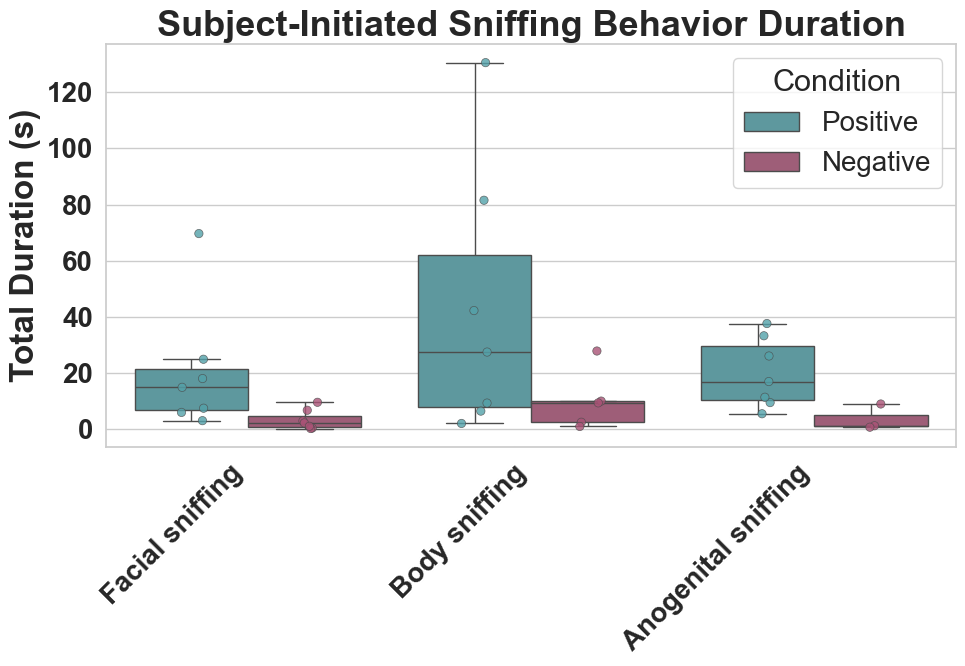

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for subject-initiated behaviors and only the sniffing types
plot_df = all_behavior_df[all_behavior_df['Subject'] == 'subject'].copy()
plot_df['Behavior'] = plot_df['Behavior'].str.capitalize()

# Keep only the sniffing behaviors
sniffing_behaviors = ['Facial sniffing', 'Body sniffing', 'Anogenital sniffing']
plot_df = plot_df[plot_df['Behavior'].isin(sniffing_behaviors)]

# Define condition colors
condition_colors = {
    'RI1': (83/255, 161/255, 169/255),  # Positive
    'RI2': (169/255, 83/255, 118/255),  # Negative
}

# Plot settings
sns.set(style="whitegrid", font_scale=1.5)
plt.figure(figsize=(10, 7))

# Boxplot with light color
sns.boxplot(
    data=plot_df,
    x='Behavior',
    y='TotalDuration',
    hue='Condition',
    order=sniffing_behaviors,
    palette={k: (*v, 0.5) for k, v in condition_colors.items()},
    showcaps=True,
    boxprops={'zorder': 1},
    fliersize=0,
)

# Overlayed stripplot with full color
sns.stripplot(
    data=plot_df,
    x='Behavior',
    y='TotalDuration',
    hue='Condition',
    order=sniffing_behaviors,
    dodge=True,
    jitter=True,
    palette={k: (*v, 1.0) for k, v in condition_colors.items()},
    alpha=0.8,
    size=6,
    edgecolor='gray',
    linewidth=0.5,
)

# Clean up legend to avoid duplicate entries and rename RI1 → Positive, RI2 → Negative
handles, labels = plt.gca().get_legend_handles_labels()
label_map = {'RI1': 'Positive', 'RI2': 'Negative'}
seen = set()
new_handles = []
new_labels = []

for handle, label in zip(handles, labels):
    if label in label_map and label_map[label] not in seen:
        new_handles.append(handle)
        new_labels.append(label_map[label])
        seen.add(label_map[label])

plt.legend(new_handles, new_labels, title='Condition', fontsize=20, title_fontsize=22)

# Label formatting
plt.title('Subject-Initiated Sniffing Behavior Duration', fontsize=26, weight='bold')
plt.xlabel('')
plt.ylabel('Total Duration (s)', fontsize=24, weight='bold')
plt.xticks(rotation=45, ha='right', fontsize=20, weight='bold')
plt.yticks(fontsize=20, weight='bold')

plt.tight_layout()
plt.show()


Paired t-tests (Positive vs Negative):

Facial sniffing: t = 1.924, p = 0.112, n = 6
Body sniffing: t = 1.818, p = 0.143, n = 5
Anogenital sniffing: t = 1.550, p = 0.261, n = 3


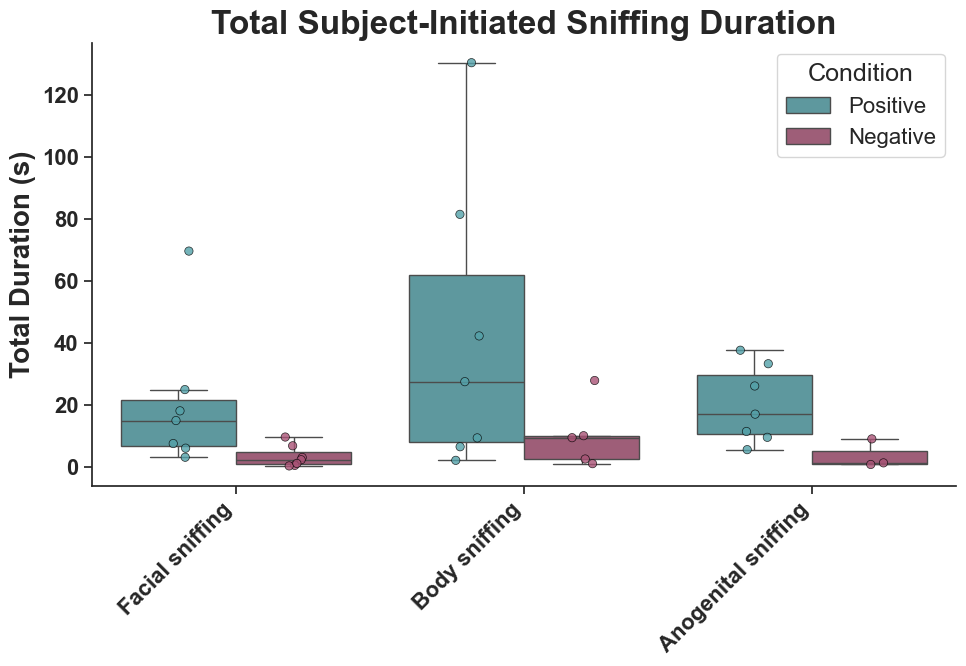

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel

# === FILTER DATA ===
# Filter for subject-initiated sniffing behaviors
plot_df = all_behavior_df[
    (all_behavior_df['Subject'] == 'subject') &
    (all_behavior_df['Behavior'].str.lower().isin(['facial sniffing', 'body sniffing', 'anogenital sniffing']))
].copy()

# Capitalize behavior labels
plot_df['Behavior'] = plot_df['Behavior'].str.capitalize()

# Extract SubjectID from the Session column (e.g., RI1_3_6 → 3_6)
plot_df['SubjectID'] = plot_df['Session'].apply(lambda x: x.split('_')[1] + '_' + x.split('_')[2])

# === PLOTTING PARAMETERS ===
behavior_order = ['Facial sniffing', 'Body sniffing', 'Anogenital sniffing']
condition_colors = {
    'RI1': (83/255, 161/255, 169/255),  # Teal = Positive
    'RI2': (169/255, 83/255, 118/255),  # Pink = Negative
}

# === PLOT ===
sns.set(style="ticks", font_scale=1.5)
plt.figure(figsize=(10, 7))

# Boxplot
sns.boxplot(
    data=plot_df,
    x='Behavior',
    y='TotalDuration',
    hue='Condition',
    order=behavior_order,
    palette={k: (*v, 0.5) for k, v in condition_colors.items()},
    showcaps=True,
    boxprops={'zorder': 1},
    fliersize=0
)

# Dot plot
sns.stripplot(
    data=plot_df,
    x='Behavior',
    y='TotalDuration',
    hue='Condition',
    order=behavior_order,
    dodge=True,
    jitter=True,
    palette={k: (*v, 1.0) for k, v in condition_colors.items()},
    alpha=0.8,
    size=6,
    edgecolor='black',
    linewidth=0.5
)

# Clean up legend (avoid duplicates)
handles, labels = plt.gca().get_legend_handles_labels()
label_map = {'RI1': 'Positive', 'RI2': 'Negative'}
seen = set()
new_handles, new_labels = [], []

for handle, label in zip(handles, labels):
    if label in label_map and label_map[label] not in seen:
        new_handles.append(handle)
        new_labels.append(label_map[label])
        seen.add(label_map[label])

plt.legend(new_handles, new_labels, title='Condition', fontsize=16, title_fontsize=18)

# === T-TESTS ===
print("Paired t-tests (Positive vs Negative):\n")
for behavior in behavior_order:
    b_df = plot_df[plot_df['Behavior'] == behavior]
    paired = b_df.pivot_table(index='SubjectID', columns='Condition', values='TotalDuration')
    paired = paired.dropna(subset=['RI1', 'RI2'])  # Only paired data
    if len(paired) >= 3:
        t_stat, p_val = ttest_rel(paired['RI1'], paired['RI2'])
        print(f"{behavior}: t = {t_stat:.3f}, p = {p_val:.3f}, n = {len(paired)}")
    else:
        print(f"{behavior}: Not enough paired data (n = {len(paired)})")

# === FORMATTING ===
plt.title('Total Subject-Initiated Sniffing Duration', fontsize=24, weight='bold')
plt.xlabel('')
plt.ylabel('Total Duration (s)', fontsize=20, weight='bold')
plt.xticks(rotation=45, ha='right', fontsize=16, weight='bold')
plt.yticks(fontsize=16, weight='bold')
sns.despine()
plt.tight_layout()
plt.show()


In [28]:
# Group by initiator, condition, and behavior
behavior_summary = (
    all_behavior_df
    .groupby(['Subject', 'Condition', 'Behavior'])['TotalDuration']
    .sum()
    .unstack(level='Condition')  # Makes RI1/RI2 into columns
    .fillna(0)
    .round(1)
)

# Display
print(behavior_summary)


Condition                           RI1    RI2
Subject      Behavior                         
social_agent Posturing              0.0    4.5
             anogenital sniffing   36.0   83.4
             body sniffing         56.5  258.6
             chasing                0.0   19.7
             facial sniffing       34.2  173.1
             fighting               0.0  453.8
             tails rattling         0.0    4.6
subject      Posturing              0.0  616.6
             anogenital sniffing  140.5   11.0
             body sniffing        299.7   50.8
             chasing                0.0    1.2
             facial sniffing      144.2   23.4


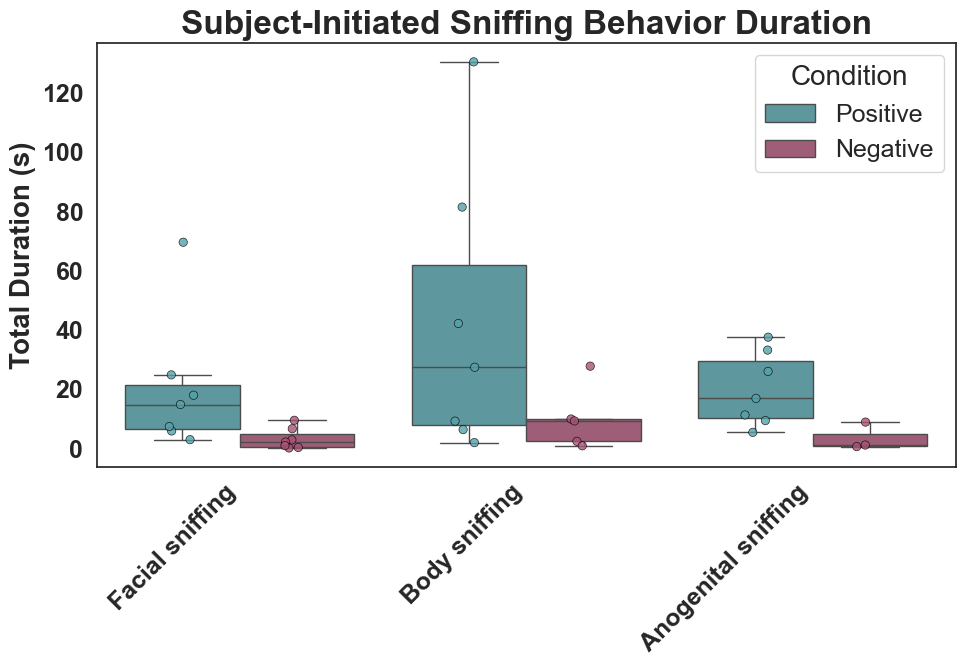


Wilcoxon Signed-Rank Tests (Subject-Initiated Sniffing):
Facial sniffing: n = 6, Wilcoxon p = 0.1562
Body sniffing: n = 5, Wilcoxon p = 0.3125
Anogenital sniffing: n = 3, Wilcoxon p = 0.2500


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import wilcoxon

# Filter for subject-initiated sniffing behaviors
plot_df = all_behavior_df[
    (all_behavior_df['Subject'] == 'subject') &
    (all_behavior_df['Behavior'].str.lower().isin(['facial sniffing', 'body sniffing', 'anogenital sniffing']))
].copy()

# Capitalize behavior labels consistently
plot_df['Behavior'] = plot_df['Behavior'].str.capitalize()

# Extract SubjectID from the Session column (format: RI1_3_6 → SubjectID: 3_6)
plot_df['SubjectID'] = plot_df['Session'].apply(lambda x: x.split('_')[1] + '_' + x.split('_')[2])

# Define plotting order and colors
behavior_order = ['Facial sniffing', 'Body sniffing', 'Anogenital sniffing']
condition_colors = {
    'RI1': (83/255, 161/255, 169/255),   # Positive
    'RI2': (169/255, 83/255, 118/255),   # Negative
}

# === PLOTTING ===
sns.set(style="white", font_scale=1.5)
plt.figure(figsize=(10, 7))

# Boxplot (light colors)
sns.boxplot(
    data=plot_df,
    x='Behavior',
    y='TotalDuration',
    hue='Condition',
    order=behavior_order,
    palette={k: (*v, 0.5) for k, v in condition_colors.items()},
    showcaps=True,
    boxprops={'zorder': 1},
    fliersize=0
)

# Dotplot (full color)
sns.stripplot(
    data=plot_df,
    x='Behavior',
    y='TotalDuration',
    hue='Condition',
    order=behavior_order,
    dodge=True,
    jitter=True,
    palette={k: (*v, 1.0) for k, v in condition_colors.items()},
    alpha=0.8,
    size=6,
    edgecolor='black',
    linewidth=0.5
)

# Remove duplicate legends and rename
handles, labels = plt.gca().get_legend_handles_labels()
label_map = {'RI1': 'Positive', 'RI2': 'Negative'}
seen = set()
new_handles = []
new_labels = []

for h, l in zip(handles, labels):
    if l in label_map and label_map[l] not in seen:
        new_handles.append(h)
        new_labels.append(label_map[l])
        seen.add(label_map[l])

plt.legend(new_handles, new_labels, title='Condition', fontsize=18, title_fontsize=20)

# Plot formatting
plt.title('Subject-Initiated Sniffing Behavior Duration', fontsize=24, weight='bold')
plt.xlabel('')
plt.ylabel('Total Duration (s)', fontsize=20, weight='bold')
plt.xticks(rotation=45, ha='right', fontsize=18, weight='bold')
plt.yticks(fontsize=18, weight='bold')
plt.tight_layout()
plt.show()

# === WILCOXON TESTS ===
print("\nWilcoxon Signed-Rank Tests (Subject-Initiated Sniffing):")
for behavior in behavior_order:
    b_df = plot_df[plot_df['Behavior'] == behavior]

    # Pivot to get paired RI1 and RI2 values per subject
    paired = b_df.pivot_table(index='SubjectID', columns='Condition', values='TotalDuration')
    paired = paired.dropna(subset=['RI1', 'RI2'])  # Drop subjects missing one condition

    if len(paired) >= 3:
        stat, p_val = wilcoxon(paired['RI1'], paired['RI2'])
        print(f"{behavior}: n = {len(paired)}, Wilcoxon p = {p_val:.4f}")
    else:
        print(f"{behavior}: Not enough paired data (n = {len(paired)})")


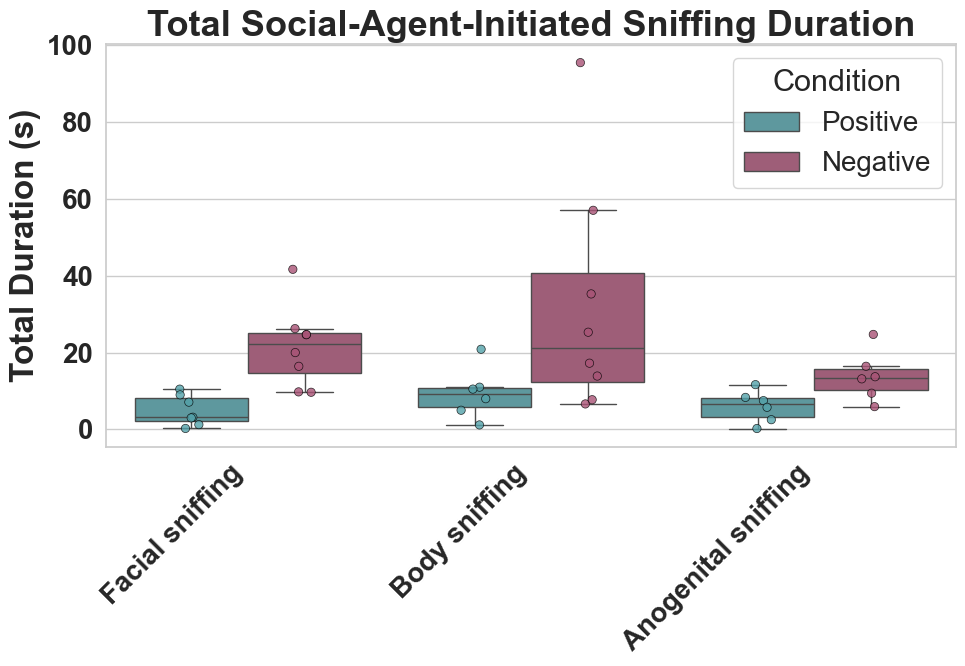

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Filter for social agent-initiated behaviors and select only sniffing behaviors
plot_df = all_behavior_df[
    (all_behavior_df['Subject'] == 'social_agent') &
    (all_behavior_df['Behavior'].str.lower().isin(['facial sniffing', 'body sniffing', 'anogenital sniffing']))
].copy()

# Capitalize behavior labels consistently
plot_df['Behavior'] = plot_df['Behavior'].str.capitalize()

# Define behavior order and condition colors
behavior_order = ['Facial sniffing', 'Body sniffing', 'Anogenital sniffing']
condition_colors = {
    'RI1': (83/255, 161/255, 169/255),  # Positive
    'RI2': (169/255, 83/255, 118/255),  # Negative
}

# Plot settings
sns.set(style="whitegrid", font_scale=1.5)
plt.figure(figsize=(10, 7))

# Boxplot (transparent)
sns.boxplot(
    data=plot_df,
    x='Behavior',
    y='TotalDuration',
    hue='Condition',
    order=behavior_order,
    palette={k: (*v, 0.5) for k, v in condition_colors.items()},
    showcaps=True,
    boxprops={'zorder': 1},
    fliersize=0,
)

# Swarmplot (full color dots)
sns.stripplot(
    data=plot_df,
    x='Behavior',
    y='TotalDuration',
    hue='Condition',
    order=behavior_order,
    dodge=True,
    jitter=True,
    palette={k: (*v, 1.0) for k, v in condition_colors.items()},
    alpha=0.8,
    size=6,
    edgecolor='black',
    linewidth=0.5,
)

# Fix legend to only show Positive and Negative once
handles, labels = plt.gca().get_legend_handles_labels()
label_map = {'RI1': 'Positive', 'RI2': 'Negative'}
seen = set()
new_handles = []
new_labels = []

for handle, label in zip(handles, labels):
    if label in label_map and label_map[label] not in seen:
        new_handles.append(handle)
        new_labels.append(label_map[label])
        seen.add(label_map[label])

plt.legend(new_handles, new_labels, title='Condition', fontsize=20, title_fontsize=22)

# Axis formatting
plt.title('Total Social-Agent-Initiated Sniffing Duration', fontsize=26, weight='bold')
plt.xlabel('')
plt.ylabel('Total Duration (s)', fontsize=24, weight='bold')
plt.xticks(rotation=45, ha='right', fontsize=20, weight='bold')
plt.yticks(fontsize=20, weight='bold')

plt.tight_layout()
plt.show()


In [21]:
print(plot_df.columns)


Index(['Subject', 'Behavior', 'TotalDuration', 'Condition', 'Session'], dtype='object')


In [22]:
plot_df

,Subject,Behavior,TotalDuration,Condition,Session
0,social_agent,Anogenital sniffing,11.656,RI1,RI1_3_6
1,social_agent,Body sniffing,1.172,RI1,RI1_3_6
2,social_agent,Facial sniffing,10.485,RI1,RI1_3_6
6,social_agent,Anogenital sniffing,0.233,RI1,RI1_4_7
7,social_agent,Facial sniffing,3.166,RI1,RI1_4_7
11,social_agent,Anogenital sniffing,7.495,RI1,RI1_2_3
12,social_agent,Body sniffing,7.996,RI1,RI1_2_3
13,social_agent,Facial sniffing,3.000,RI1,RI1_2_3
17,social_agent,Anogenital sniffing,8.335,RI1,RI1_4_8
18,social_agent,Body sniffing,10.997,RI1,RI1_4_8


Paired t-tests (Positive vs Negative):

Facial sniffing: t=-5.890, p=0.001, n=7
Body sniffing: t=-2.767, p=0.039, n=6
Anogenital sniffing: t=-2.289, p=0.071, n=6


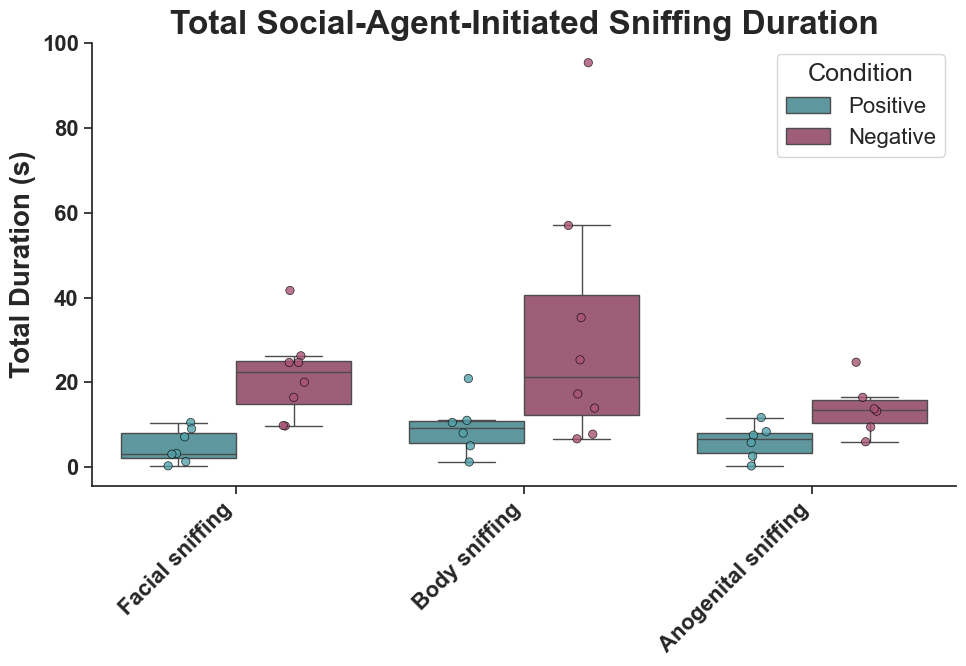

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel

# === FILTER AND PREPARE DATA ===
# Filter for social agent-initiated sniffing behaviors only
plot_df = all_behavior_df[
    (all_behavior_df['Subject'] == 'social_agent') &
    (all_behavior_df['Behavior'].str.lower().isin(['facial sniffing', 'body sniffing', 'anogenital sniffing']))
].copy()

# Capitalize behavior names
plot_df['Behavior'] = plot_df['Behavior'].str.capitalize()

# Extract SubjectID from 'Session' (e.g., "RI1_3_6" → "3_6")
plot_df['SubjectID'] = plot_df['Session'].apply(lambda x: x.split('_')[1] + '_' + x.split('_')[2])

# === PLOTTING PARAMETERS ===
behavior_order = ['Facial sniffing', 'Body sniffing', 'Anogenital sniffing']
condition_colors = {
    'RI1': (83/255, 161/255, 169/255),   # Teal (Positive)
    'RI2': (169/255, 83/255, 118/255),   # Pink (Negative)
}

# === PLOT ===
sns.set(style="ticks", font_scale=1.5)
plt.figure(figsize=(10, 7))

# Boxplot
sns.boxplot(
    data=plot_df,
    x='Behavior',
    y='TotalDuration',
    hue='Condition',
    order=behavior_order,
    palette={k: (*v, 0.5) for k, v in condition_colors.items()},
    showcaps=True,
    boxprops={'zorder': 1},
    fliersize=0
)

# Stripplot (dots)
sns.stripplot(
    data=plot_df,
    x='Behavior',
    y='TotalDuration',
    hue='Condition',
    order=behavior_order,
    dodge=True,
    jitter=True,
    palette={k: (*v, 1.0) for k, v in condition_colors.items()},
    alpha=0.8,
    size=6,
    edgecolor='black',
    linewidth=0.5
)

# Remove duplicate legend entries
handles, labels = plt.gca().get_legend_handles_labels()
label_map = {'RI1': 'Positive', 'RI2': 'Negative'}
seen = set()
new_handles = []
new_labels = []

for handle, label in zip(handles, labels):
    if label in label_map and label_map[label] not in seen:
        new_handles.append(handle)
        new_labels.append(label_map[label])
        seen.add(label_map[label])

plt.legend(new_handles, new_labels, title='Condition', fontsize=16, title_fontsize=18)

# === STATS: Paired t-tests ===
print("Paired t-tests (Positive vs Negative):\n")
for behavior in behavior_order:
    b_df = plot_df[plot_df['Behavior'] == behavior]
    paired = b_df.pivot_table(index='SubjectID', columns='Condition', values='TotalDuration')
    paired = paired.dropna(subset=['RI1', 'RI2'])
    if len(paired) >= 3:
        stat, pval = ttest_rel(paired['RI1'], paired['RI2'])
        print(f"{behavior}: t={stat:.3f}, p={pval:.3f}, n={len(paired)}")
    else:
        print(f"{behavior}: Not enough pairs for test (n={len(paired)})")

# === FINAL PLOT FORMATTING ===
plt.title('Total Social-Agent-Initiated Sniffing Duration', fontsize=24, weight='bold')
plt.xlabel('')
plt.ylabel('Total Duration (s)', fontsize=20, weight='bold')
plt.xticks(rotation=45, ha='right', fontsize=16, weight='bold')
plt.yticks(fontsize=16, weight='bold')
sns.despine()
plt.tight_layout()
plt.show()


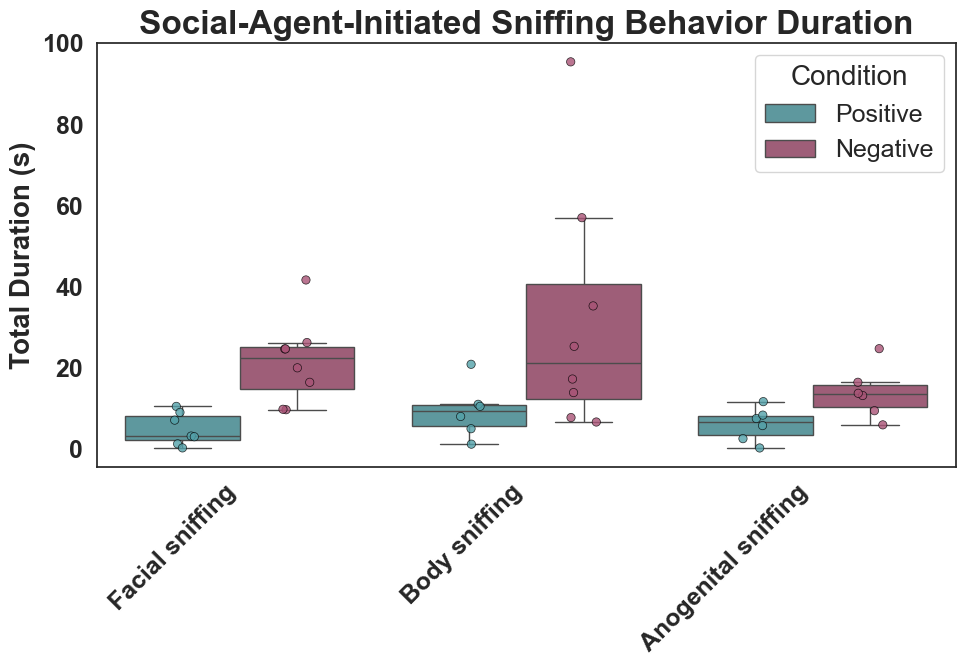


Wilcoxon Signed-Rank Tests (Social-Agent-Initiated Sniffing):
Facial sniffing: n = 7, Wilcoxon p = 0.0156
Body sniffing: n = 6, Wilcoxon p = 0.0312
Anogenital sniffing: n = 6, Wilcoxon p = 0.0312


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import wilcoxon

# Filter for social-agent-initiated sniffing behaviors
plot_df = all_behavior_df[
    (all_behavior_df['Subject'] == 'social_agent') &
    (all_behavior_df['Behavior'].str.lower().isin(['facial sniffing', 'body sniffing', 'anogenital sniffing']))
].copy()

# Capitalize behavior labels consistently
plot_df['Behavior'] = plot_df['Behavior'].str.capitalize()

# Extract SubjectID from the Session column (format: RI1_3_6 → SubjectID: 3_6)
plot_df['SubjectID'] = plot_df['Session'].apply(lambda x: x.split('_')[1] + '_' + x.split('_')[2])

# Define behavior order and condition colors
behavior_order = ['Facial sniffing', 'Body sniffing', 'Anogenital sniffing']
condition_colors = {
    'RI1': (83/255, 161/255, 169/255),   # Positive
    'RI2': (169/255, 83/255, 118/255),   # Negative
}

# === PLOTTING ===
sns.set(style="white", font_scale=1.5)
plt.figure(figsize=(10, 7))

# Boxplot
sns.boxplot(
    data=plot_df,
    x='Behavior',
    y='TotalDuration',
    hue='Condition',
    order=behavior_order,
    palette={k: (*v, 0.5) for k, v in condition_colors.items()},
    showcaps=True,
    boxprops={'zorder': 1},
    fliersize=0
)

# Overlay dotplot
sns.stripplot(
    data=plot_df,
    x='Behavior',
    y='TotalDuration',
    hue='Condition',
    order=behavior_order,
    dodge=True,
    jitter=True,
    palette={k: (*v, 1.0) for k, v in condition_colors.items()},
    alpha=0.8,
    size=6,
    edgecolor='black',
    linewidth=0.5
)

# Clean legend
handles, labels = plt.gca().get_legend_handles_labels()
label_map = {'RI1': 'Positive', 'RI2': 'Negative'}
seen = set()
new_handles = []
new_labels = []

for h, l in zip(handles, labels):
    if l in label_map and label_map[l] not in seen:
        new_handles.append(h)
        new_labels.append(label_map[l])
        seen.add(label_map[l])

plt.legend(new_handles, new_labels, title='Condition', fontsize=18, title_fontsize=20)

# Format axes
plt.title('Social-Agent-Initiated Sniffing Behavior Duration', fontsize=24, weight='bold')
plt.xlabel('')
plt.ylabel('Total Duration (s)', fontsize=20, weight='bold')
plt.xticks(rotation=45, ha='right', fontsize=18, weight='bold')
plt.yticks(fontsize=18, weight='bold')
plt.tight_layout()
plt.show()

# === WILCOXON TESTS ===
print("\nWilcoxon Signed-Rank Tests (Social-Agent-Initiated Sniffing):")
for behavior in behavior_order:
    b_df = plot_df[plot_df['Behavior'] == behavior]

    # Pivot to get paired RI1 and RI2 values per subject
    paired = b_df.pivot_table(index='SubjectID', columns='Condition', values='TotalDuration')
    paired = paired.dropna(subset=['RI1', 'RI2'])

    if len(paired) >= 3:
        stat, p_val = wilcoxon(paired['RI1'], paired['RI2'])
        print(f"{behavior}: n = {len(paired)}, Wilcoxon p = {p_val:.4f}")
    else:
        print(f"{behavior}: Not enough paired data (n = {len(paired)})")


In [37]:
print(plot_df.groupby(['Condition', 'Behavior'])['TotalDuration'].median())


Condition  Behavior           
RI1        Anogenital sniffing     6.6240
           Body sniffing           9.2465
           Facial sniffing         3.1660
RI2        Anogenital sniffing    13.4400
           Body sniffing          21.2660
           Chasing                 3.2975
           Facial sniffing        22.3320
           Fighting               43.5250
           Posturing               4.5330
           Tails rattling          1.8000
Name: TotalDuration, dtype: float64


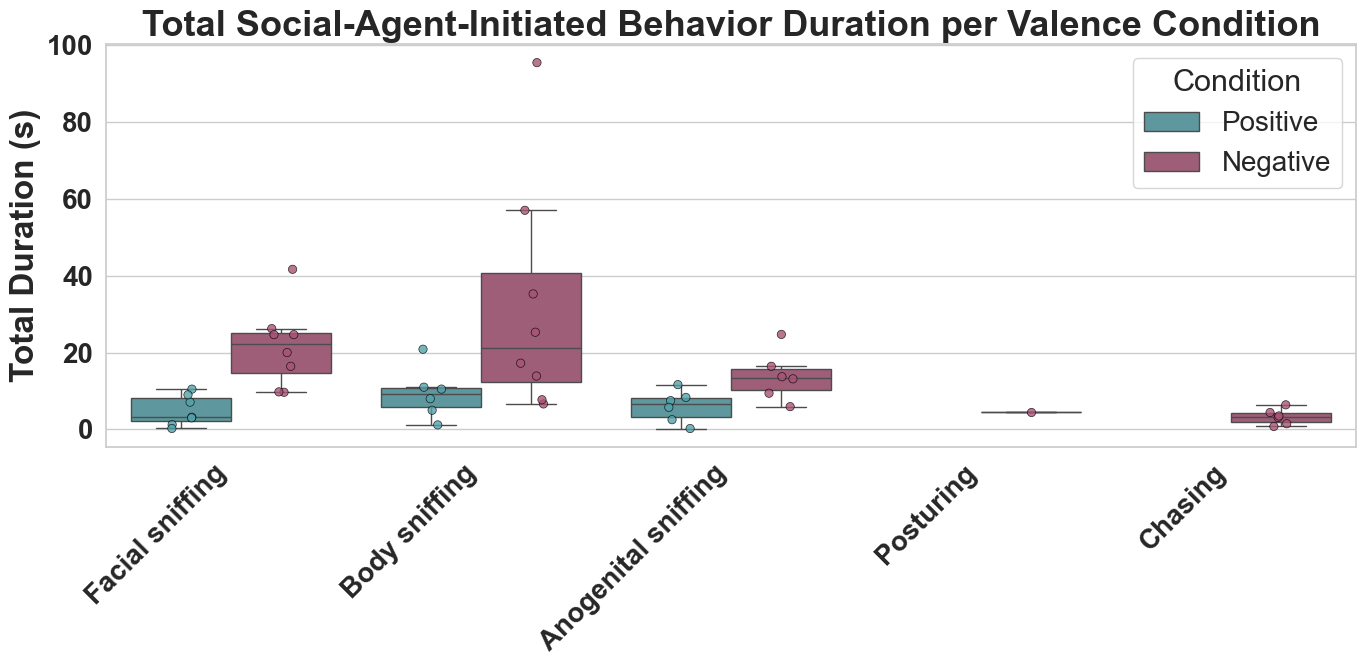

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Filter for social agent-initiated behaviors
plot_df = all_behavior_df[all_behavior_df['Subject'] == 'social_agent'].copy()
plot_df['Behavior'] = plot_df['Behavior'].str.capitalize()

# Define behavior order and condition colors
behavior_order = ['Facial sniffing', 'Body sniffing', 'Anogenital sniffing', 'Posturing', 'Chasing']
condition_colors = {
    'RI1': (83/255, 161/255, 169/255),  # Positive
    'RI2': (169/255, 83/255, 118/255),  # Negative
}

# Plot settings
sns.set(style="whitegrid", font_scale=1.5)
plt.figure(figsize=(14, 7))

# Boxplot (transparent)
sns.boxplot(
    data=plot_df,
    x='Behavior',
    y='TotalDuration',
    hue='Condition',
    order=behavior_order,
    palette={k: (*v, 0.5) for k, v in condition_colors.items()},
    showcaps=True,
    boxprops={'zorder': 1},
    fliersize=0,
)

# Swarmplot (full color dots)
sns.stripplot(
    data=plot_df,
    x='Behavior',
    y='TotalDuration',
    hue='Condition',
    order=behavior_order,
    dodge=True,
    jitter=True,
    palette={k: (*v, 1.0) for k, v in condition_colors.items()},
    alpha=0.8,
    size=6,
    edgecolor='black',
    linewidth=0.5,
)

# Fix legend to only show Positive and Negative once
handles, labels = plt.gca().get_legend_handles_labels()
label_map = {'RI1': 'Positive', 'RI2': 'Negative'}
seen = set()
new_handles = []
new_labels = []

for handle, label in zip(handles, labels):
    if label in label_map and label_map[label] not in seen:
        new_handles.append(handle)
        new_labels.append(label_map[label])
        seen.add(label_map[label])

plt.legend(new_handles, new_labels, title='Condition', fontsize=20, title_fontsize=22)

# Axis formatting
plt.title('Total Social-Agent-Initiated Behavior Duration per Valence Condition', fontsize=26, weight='bold')
plt.xlabel('')
plt.ylabel('Total Duration (s)', fontsize=24, weight='bold')
plt.xticks(rotation=45, ha='right', fontsize=20, weight='bold')
plt.yticks(fontsize=20, weight='bold')

plt.tight_layout()
plt.show()


In [26]:
all_behavior_df

,Subject,Behavior,TotalDuration,Condition,Session
0,social_agent,anogenital sniffing,11.656,RI1,RI1_3_6
1,social_agent,body sniffing,1.172,RI1,RI1_3_6
2,social_agent,facial sniffing,10.485,RI1,RI1_3_6
3,subject,anogenital sniffing,16.998,RI1,RI1_3_6
4,subject,body sniffing,2.068,RI1,RI1_3_6
5,subject,facial sniffing,3.069,RI1,RI1_3_6
6,social_agent,anogenital sniffing,0.233,RI1,RI1_4_7
7,social_agent,facial sniffing,3.166,RI1,RI1_4_7
8,subject,anogenital sniffing,26.096,RI1,RI1_4_7
9,subject,body sniffing,6.465,RI1,RI1_4_7


C:\Users\sjs93\AppData\Local\Temp\ipykernel_28092\169615508.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


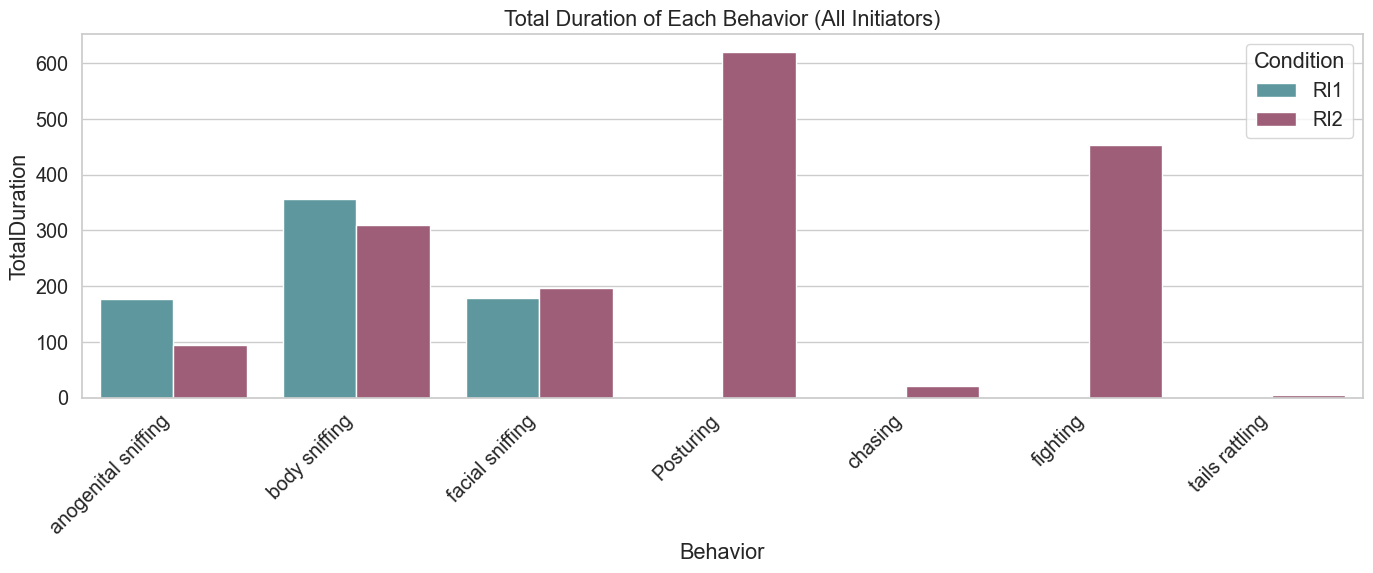

In [29]:
sns.set(style="whitegrid", font_scale=1.3)
plt.figure(figsize=(14, 6))
sns.barplot(
    data=all_behavior_df,
    x='Behavior',
    y='TotalDuration',
    hue='Condition',
    estimator='sum',
    ci=None,
    palette={'RI1': (83/255, 161/255, 169/255), 'RI2': (169/255, 83/255, 118/255)},
)
plt.title('Total Duration of Each Behavior (All Initiators)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


C:\Users\sjs93\AppData\Local\Temp\ipykernel_28092\3643160496.py:14: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g = sns.catplot(


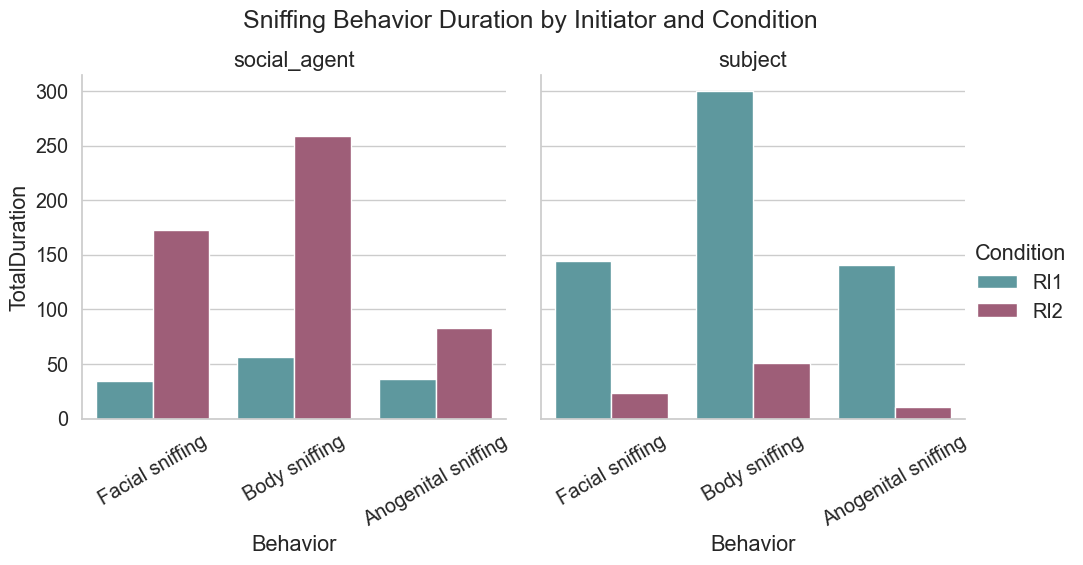

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure behavior labels are consistently capitalized
all_behavior_df['Behavior'] = all_behavior_df['Behavior'].str.capitalize()

# Define the behavior order you want
sniffing_behaviors = ['Facial sniffing', 'Body sniffing', 'Anogenital sniffing']

# Filter to just sniffing behaviors
sniff_df = all_behavior_df[all_behavior_df['Behavior'].isin(sniffing_behaviors)]

# Plot: Behavior duration by initiator and condition
g = sns.catplot(
    data=sniff_df,
    x='Behavior',
    y='TotalDuration',
    hue='Condition',
    col='Subject',
    kind='bar',
    order=sniffing_behaviors,
    estimator='sum',
    ci=None,
    height=5,
    aspect=1,
    palette={
        'RI1': (83/255, 161/255, 169/255),  # Positive
        'RI2': (169/255, 83/255, 118/255)   # Negative
    }
)

# Formatting
g.set_titles("{col_name}")
g.set_xticklabels(rotation=30)
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle('Sniffing Behavior Duration by Initiator and Condition', fontsize=18)

plt.show()


C:\Users\sjs93\AppData\Local\Temp\ipykernel_28092\1486877006.py:14: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g = sns.catplot(


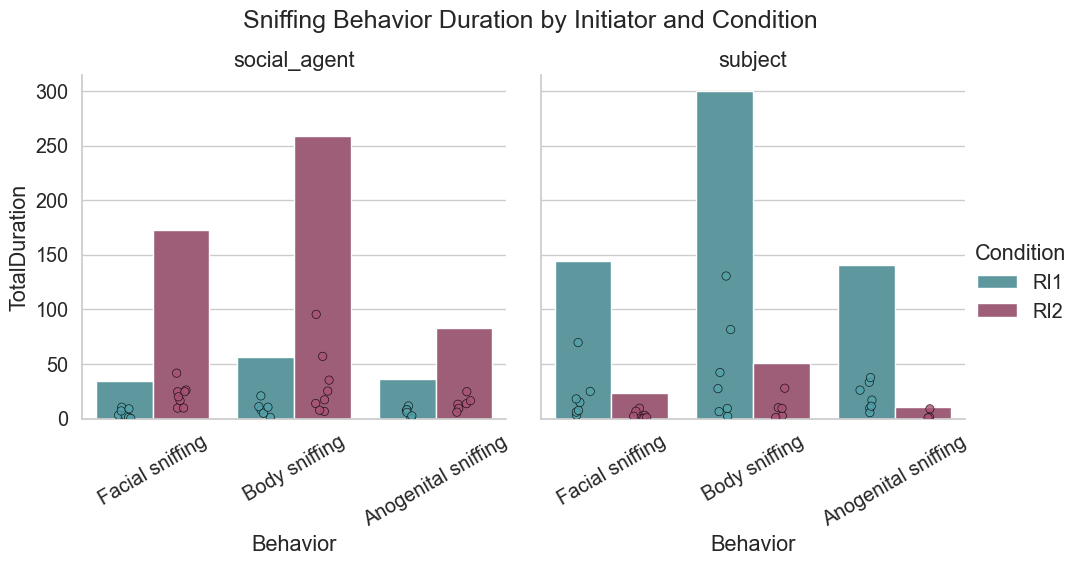

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure behavior labels are consistently capitalized
all_behavior_df['Behavior'] = all_behavior_df['Behavior'].str.capitalize()

# Define the behavior order
sniffing_behaviors = ['Facial sniffing', 'Body sniffing', 'Anogenital sniffing']

# Filter to sniffing behaviors only
sniff_df = all_behavior_df[all_behavior_df['Behavior'].isin(sniffing_behaviors)]

# Create the base catplot with bars
g = sns.catplot(
    data=sniff_df,
    x='Behavior',
    y='TotalDuration',
    hue='Condition',
    col='Subject',
    kind='bar',
    order=sniffing_behaviors,
    estimator='sum',
    ci=None,
    height=5,
    aspect=1,
    palette={
        'RI1': (83/255, 161/255, 169/255),  # Positive
        'RI2': (169/255, 83/255, 118/255)   # Negative
    }
)

# Overlay stripplot with subject-level points
for ax, subject in zip(g.axes[0], sniff_df['Subject'].unique()):
    sub_df = sniff_df[sniff_df['Subject'] == subject]
    sns.stripplot(
        data=sub_df,
        x='Behavior',
        y='TotalDuration',
        hue='Condition',
        order=sniffing_behaviors,
        dodge=True,
        alpha=0.8,
        size=6,
        edgecolor='black',
        linewidth=0.5,
        palette={
            'RI1': (83/255, 161/255, 169/255),
            'RI2': (169/255, 83/255, 118/255)
        },
        ax=ax
    )
    # Remove duplicate legend
    ax.legend_.remove()

# Titles and layout
g.set_titles("{col_name}")
g.set_xticklabels(rotation=30)
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle('Sniffing Behavior Duration by Initiator and Condition', fontsize=18)

plt.show()
